# A1 — Spot the Right Scaler

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

তিনটি feature দেওয়া আছে:

| Feature | বিবরণ |
|---|---|
| `Apartment_price_BDT` | কিছু luxury penthouse-এর কারণে **outlier** আছে |
| `Skin_temperature_C` | wearable device থেকে মাপা — মান শুধু **30 থেকে 36**-এর মধ্যে |
| `Daily_app_opens` | অনেক মান **0**, কিছু power user অনেক বেশি খোলে — **outlier** আছে |

প্রতিটি feature-এর জন্য:
- সবচেয়ে উপযুক্ত **scaler** বেছে নিতে হবে
- **এক লাইনে** কারণ ব্যাখ্যা করতে হবে
- একটি **numeric example** দিয়ে দেখাতে হবে


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- বাস্তব feature দেখে **outlier আছে কিনা** সেটা চিনতে পারব।
- তিনটি scaler-এর মধ্যে **কোনটি কোথায় মানানসই** সেটার judgment তৈরি হবে।
- Numeric example-এ দেখব কীভাবে ভুল scaler বেছে নিলে data **বিকৃত** হয়।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

প্রতিটি feature দেখে নিজেকে দুটো প্রশ্ন করতে হবে:

> **প্রশ্ন ১: এই feature-এ কি outlier আছে?**
> **প্রশ্ন ২: Data-র range কি bounded (সীমাবদ্ধ)?**

| পরিস্থিতি | সঠিক Scaler |
|---|---|
| Outlier আছে | **Robust Scaler** → median ও IQR ব্যবহার করে, outlier-এ প্রভাবিত হয় না |
| Outlier নেই, range bounded | **Min-Max Scaler** → [0, 1]-এ সুন্দরভাবে আসে |
| Outlier নেই, normal distribution-এর মতো | **Standard Scaler** → mean=0, std=1 |

### এই problem-এর তিনটি feature-এ প্রশ্নের উত্তর:

| Feature | Outlier? | Range bounded? | সিদ্ধান্ত |
|---|---|---|---|
| `Apartment_price_BDT` | ✅ হ্যাঁ (luxury penthouse) | ❌ না | **Robust Scaler** |
| `Skin_temperature_C` | ❌ না | ✅ হ্যাঁ (30–36) | **Min-Max Scaler** |
| `Daily_app_opens` | ✅ হ্যাঁ (power users) | ❌ না | **Robust Scaler** |
| যেকোনো feature | ✅ হ্যাঁ | ✅ হ্যাঁ | **Robust Scaler** — outlier থাকলে bounded range গুরুত্বহীন, outlier আগে সামলাতে হবে |
| যেকোনো feature | ❌ না | ❌ না | **Standard Scaler** — outlier নেই, range-ও fixed না, distribution normal-এর মতো ধরে নিয়ে standardize করাই সঠিক |

- **দুটোই YES** (outlier আছে + range bounded): Robust Scaler জেতে — কারণ outlier থাকলে Min-Max-এর bounded range কোনো কাজে আসে না, outlier পুরো scaling নষ্ট করে দেয়।
- **দুটোই NO** (outlier নেই + range bounded না): Standard Scaler (Standardization) — data roughly normal-এর মতো distribute হয়, তাই mean=0, std=1 করাটাই সবচেয়ে নিরাপদ।



---

## 🛠️ Problem Solve করার Approach

**Step 1:** তিনটি feature-এর জন্য synthetic data তৈরি করা।

**Step 2:** Boxplot দিয়ে outlier দৃশ্যমান করা।

**Step 3:** প্রতিটি feature-এ সঠিক scaler apply করা এবং ভুল scaler-এর সাথে তুলনা করা।

**Step 4:** Numeric example দিয়ে justify করা।


## Step 1: Library Import ও Synthetic Data তৈরি

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

np.random.seed(7)

# Apartment_price_BDT: most 30L-80L, a few penthouses at 5Cr+
apartment_price = np.concatenate(
    [
        np.random.randint(3_000_000, 8_000_000, 18),
        [50_000_000, 80_000_000]        # luxury penthouses — outliers
    ]
)

# Skin_temperature_C: strictly 30 to 36, no outliers
skin_temp = np.random.uniform(30, 36, 20)

# Daily_app_opens: most 0-5, a few power users open 200+ times
daily_opens = np.concatenate(
    [
        np.random.randint(0, 6, 17),
        [0, 0, 250]                     # power user — outlier
    ]
)

df = pd.DataFrame({
    'Apartment_price_BDT': apartment_price,
    'Skin_temperature_C':  skin_temp.round(2),
    'Daily_app_opens':     daily_opens
})

print(df.to_string(index=False))


 Apartment_price_BDT  Skin_temperature_C  Daily_app_opens
             3585903               31.73                2
             6335364               35.46                1
             5671129               31.28                3
             5632182               32.71                0
             6905091               35.59                5
             6474327               30.15                4
             5176615               33.60                0
             3854551               35.70                5
             7812360               31.38                4
             6461465               33.29                3
             6697370               35.45                1
             4225608               30.80                3
             4808358               33.14                3
             7315007               34.50                3
             6268999               34.01                1
             3351148               32.81                3
             4

`np.concatenate` দিয়ে সাধারণ মানের সাথে outlier জুড়ে দেওয়া হয়েছে।
`np.random.uniform(30, 36)` — 30 থেকে 36-এর মধ্যে random float তৈরি করে।


## Step 2: Boxplot দিয়ে Outlier দেখা

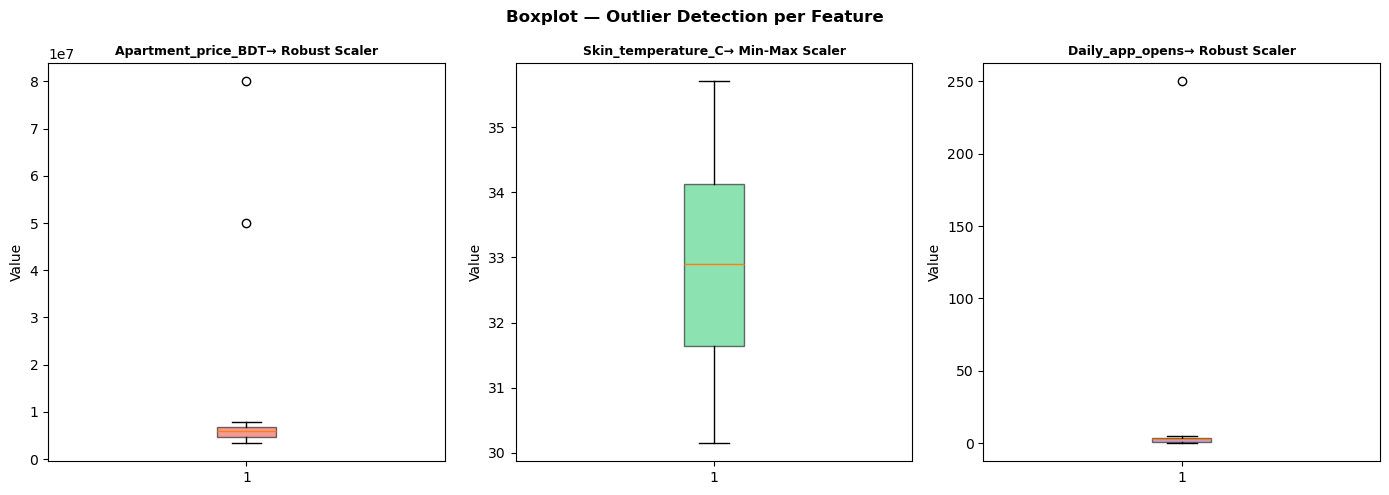

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

features = ['Apartment_price_BDT', 'Skin_temperature_C', 'Daily_app_opens']
colors   = ['#e74c3c', '#2ecc71', '#9b59b6']
scalers  = ['→ Robust Scaler', '→ Min-Max Scaler', '→ Robust Scaler']

for ax, feature, color, scaler in zip(axes, features, colors, scalers):
    ax.boxplot(df[feature], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.55))
    ax.set_title(f"{feature}{scaler}", fontsize=9, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Boxplot — Outlier Detection per Feature', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Box-এর বাইরের বিন্দু = **outlier**।
- `Apartment_price_BDT` → উপরে দুটো বিন্দু (penthouses)।
- `Skin_temperature_C` → কোনো বিন্দু নেই — outlier-মুক্ত।
- `Daily_app_opens` → উপরে একটি বিন্দু (power user)।


---

## Feature (a): `Apartment_price_BDT` → Robust Scaler

**কারণ (এক লাইনে):** Luxury penthouse-এর outlier থাকায় Min-Max ব্যবহার করলে বাকি সব apartment-এর মান 0-এর কাছে চাপা পড়বে — Robust Scaler median ও IQR দিয়ে সেই সমস্যা এড়ায়।

### Numeric Example:
Sample values: **30L, 50L, 65L, 5Cr** (BDT)


In [10]:
sample_price = np.array([[3_000_000],
                         [5_000_000],
                         [6_500_000],
                         [50_000_000]])  # penthouse outlier

robust_price = RobustScaler().fit_transform(sample_price)
minmax_price = MinMaxScaler().fit_transform(sample_price)

price_compare = pd.DataFrame({
    'Price_BDT': sample_price.flatten(),
    'Robust': robust_price.flatten().round(4),
    'Min-Max': minmax_price.flatten().round(4)
})
print("Apartment_price_BDT — Robust vs Min-Max:")
print(price_compare.to_string(index=False))


Apartment_price_BDT — Robust vs Min-Max:
 Price_BDT  Robust  Min-Max
   3000000 -0.2136   0.0000
   5000000 -0.0583   0.0426
   6500000  0.0583   0.0745
  50000000  3.4369   1.0000


**লক্ষ্য করো:**
- **Min-Max**: penthouse (5Cr) = 1.0, কিন্তু 30L–65L-এর সব মান **0.00–0.08**-এর মধ্যে — পার্থক্য বোঝাই যাচ্ছে না।
- **Robust**: 30L–65L-এর মানগুলো নিজেদের মধ্যে **পরিষ্কার ব্যবধান** রেখেছে। ✅


---

## Feature (b): `Skin_temperature_C` → Min-Max Scaler

**কারণ (এক লাইনে):** Data সম্পূর্ণ 30–36°C-এর মধ্যে bounded, কোনো outlier নেই — Min-Max Scaler সুন্দরভাবে [0, 1]-এ নিয়ে আসে এবং প্রতিটি মানের relative position অক্ষুণ্ণ থাকে।

### Numeric Example:
Sample values: **30, 32, 34, 36** °C


In [9]:
sample_temp = np.array([[30], [32], [34], [36]])

minmax_temp = MinMaxScaler().fit_transform(sample_temp)
robust_temp = RobustScaler().fit_transform(sample_temp)

temp_compare = pd.DataFrame({
    'Temp_C': sample_temp.flatten(),
    'Min-Max': minmax_temp.flatten().round(4),
    'Robust': robust_temp.flatten().round(4)
})
print("Skin_temperature_C — Min-Max vs Robust:")
print(temp_compare.to_string(index=False))


Skin_temperature_C — Min-Max vs Robust:
 Temp_C  Min-Max  Robust
     30   0.0000 -1.0000
     32   0.3333 -0.3333
     34   0.6667  0.3333
     36   1.0000  1.0000


**লক্ষ্য করো:**
- **Min-Max**: 30→0.0, 36→1.0 — perfectly bounded, সব মানের relative position ঠিক আছে। ✅
- **Robust**: outlier না থাকলেও ঠিকঠাক কাজ করে, তবে [0,1]-এ আসে না — interpretability কম।


---

## Feature (c): `Daily_app_opens` → Robust Scaler

**কারণ (এক লাইনে):** অধিকাংশ user 0–5 বার app খোলে কিন্তু কিছু power user 250+ বার খোলে — এই extreme outlier-এর কারণে Min-Max ব্যবহারে 0–5-এর সব মান প্রায় 0-তে চাপা পড়বে, তাই Robust Scaler প্রয়োজন।

### Numeric Example:
Sample values: **0, 2, 4, 250** (opens/day)


In [11]:
sample_opens = np.array([[0], [2], [4], [250]])   # 250 = power user outlier

robust_opens = RobustScaler().fit_transform(sample_opens)
minmax_opens = MinMaxScaler().fit_transform(sample_opens)

opens_compare = pd.DataFrame({
    'App_Opens': sample_opens.flatten(),
    'Robust':    robust_opens.flatten().round(4),
    'Min-Max':   minmax_opens.flatten().round(4)
})
print("Daily_app_opens — Robust vs Min-Max:")
print(opens_compare.to_string(index=False))


Daily_app_opens — Robust vs Min-Max:
 App_Opens  Robust  Min-Max
         0 -0.0469    0.000
         2 -0.0156    0.008
         4  0.0156    0.016
       250  3.8594    1.000


**লক্ষ্য করো:**
- **Min-Max**: 250 outlier = 1.0, কিন্তু 0–4-এর সব মান **0.000–0.016**-এর মধ্যে — মডেল এদের পার্থক্য ধরতে পারবে না।
- **Robust**: 0–4-এর মানগুলো নিজেদের মধ্যে **আলাদা ব্যবধান** বজায় রেখেছে। ✅


## Final Summary — তিনটি Feature একসাথে Scale করা

In [12]:
apt   = df[['Apartment_price_BDT']]
temp  = df[['Skin_temperature_C']]
opens = df[['Daily_app_opens']]

df['Apt_Scaled']   = RobustScaler().fit_transform(apt)
df['Temp_Scaled']  = MinMaxScaler().fit_transform(temp)
df['Opens_Scaled'] = RobustScaler().fit_transform(opens)

summary = df[['Apartment_price_BDT', 'Apt_Scaled',
              'Skin_temperature_C',  'Temp_Scaled',
              'Daily_app_opens',     'Opens_Scaled']].head(20)

print(summary.round(4).to_string(index=False))


 Apartment_price_BDT  Apt_Scaled  Skin_temperature_C  Temp_Scaled  Daily_app_opens  Opens_Scaled
             3585903     -1.1909               31.73       0.2847                2       -0.4444
             6335364      0.1825               35.46       0.9568                1       -0.8889
             5671129     -0.1493               31.28       0.2036                3        0.0000
             5632182     -0.1688               32.71       0.4613                0       -1.3333
             6905091      0.4670               35.59       0.9802                5        0.8889
             6474327      0.2519               30.15       0.0000                4        0.4444
             5176615     -0.3963               33.60       0.6216                0       -1.3333
             3854551     -1.0567               35.70       1.0000                5        0.8889
             7812360      0.9202               31.38       0.2216                4        0.4444
             6461465      0.24

`fit_transform()` — scaler প্রথমে data দেখে শেখে (fit), তারপর transform করে।
প্রতিটি feature আলাদাভাবে scale হয়েছে — নিজের median/IQR বা min/max ব্যবহার করে।

### ✅ এক নজরে সিদ্ধান্ত:

| Feature | Scaler | কারণ |
|---|---|---|
| `Apartment_price_BDT` | **Robust** | Luxury penthouse outlier আছে |
| `Skin_temperature_C` | **Min-Max** | Bounded range (30–36), outlier নেই |
| `Daily_app_opens` | **Robust** | Power user outlier আছে, বেশিরভাগ মান 0 |


---